# Dask vs Numpy

This notebook benchmarks **Dask** against **NumPy** (CPU) for matrix multiplication and tabular data I/O. The goal is to understand when Dask's parallel, chunked execution offers a speed advantage over NumPy's eager, single-threaded operations.
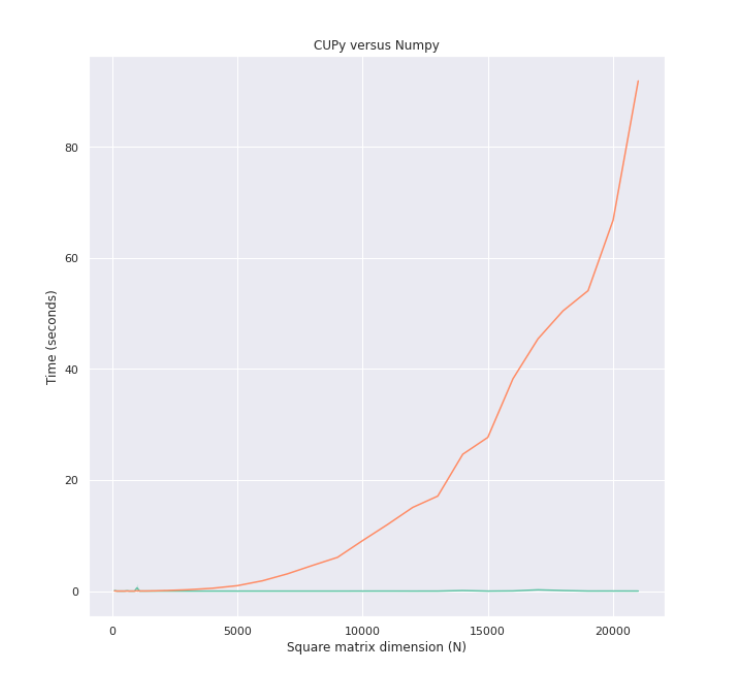

In [ ]:
%%capture
!pip install dask tqdm seaborn faker

## Setup

We install the core libraries needed for this notebook:
- **dask** — parallel computing library that scales NumPy/Pandas workflows
- **tqdm** — progress bars for loops
- **seaborn** — statistical visualization built on Matplotlib
- **faker** — generates realistic fake data for benchmarking

In [ ]:
# import libraries
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm, trange
import time
import dask.array as da

## Imports

We import NumPy for standard array operations, Pandas for tabular data, `tqdm` for progress tracking, and `dask.array` as the Dask counterpart to NumPy arrays.

In [ ]:
N = 100000
x = da.random.random((N,N),chunks=(1000, 1000))
x

### Dask arrays and chunking

Here we create a 100,000 × 100,000 Dask array (about 80 GB if fully materialised). Dask never allocates all that memory at once — it divides the array into **chunks** of 1,000 × 1,000 elements and only computes each chunk when needed. The cell output shows the task graph metadata rather than the actual values.

## Dask versus Numpy

In [ ]:
SEED = 6174

def npmultiply(N=10):
    rng = np.random.default_rng(SEED)
    a = rng.random((N, N))
    b = rng.random((N, N))
    t1 = time.time()
    c = np.matmul(a, b)
    t2 = time.time()
    return t2 - t1

### Benchmark functions

`npmultiply(N)` creates two N×N matrices with NumPy and times a single `np.matmul` call. A fixed random seed (`SEED = 6174`) ensures both libraries operate on equivalent data, making the timing comparison fair.

In [ ]:
def daskmultiply(N=10):
    chunk = min(N, 1000)
    rng = da.random.RandomState(SEED)
    a = rng.random((N, N), chunks=(chunk, chunk))
    b = rng.random((N, N), chunks=(chunk, chunk))
    t1 = time.time()
    c = da.matmul(a, b).compute()
    t2 = time.time()
    return t2 - t1

`daskmultiply(N)` mirrors the NumPy version but uses `dask.array`. The key difference is the `.compute()` call at the end — Dask builds a lazy task graph first and only executes it when `.compute()` is invoked. The chunk size is capped at 1,000 so very small matrices don't have unnecessarily small chunks.

In [ ]:
records = []
for N in tqdm(range(100, 2500, 10)):
    records.append({'N': N + 1, 'Dask': daskmultiply(N + 1), 'CPU': npmultiply(N + 1)})

df = pd.DataFrame(records)

### Running the benchmark

We sweep matrix sizes from N=100 to N=2500 in steps of 10, recording wall-clock time for both `daskmultiply` and `npmultiply` at each size. Results are collected in a list of dicts and converted to a Pandas DataFrame for plotting.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(rc={"figure.figsize":(10, 10)}) #width=3, #height=4
sns.set_style('darkgrid')
sns.set_palette('Set2')
sns.lineplot(data=df, x='N', y='Dask', label='Dask')
sns.lineplot(data=df, x='N', y='CPU', label='CPU')
plt.title('Dask versus Numpy')
plt.xlabel('Square matrix dimension (N)')
plt.ylabel('Time (seconds)')
plt.legend(loc="upper left")
plt.show()

### Results

The line plot shows elapsed time (seconds) vs. matrix dimension for Dask and NumPy. For small matrices, Dask is slower because task-graph scheduling overhead dominates. As N grows, Dask's chunked parallel execution closes the gap — and can eventually outperform NumPy when matrices no longer fit comfortably in cache or when multiple CPU cores are engaged.

## Large datasets

In [ ]:
from faker import Faker
fake = Faker()
Faker.seed(1234567890)

file = open('fake_dataset.tsv', 'w')
#from header remove address
file.write('SSN\tName\tPhone number\tCompany\tBank\tCredit Card\tCredit Card Expiration\tCredit Card Provider\n')

# not really large
for n in tqdm(range(25000)):
    ssn = fake.ssn()
    name = fake.name()
    address = fake.address() #ignore
    phone_number = fake.phone_number()
    company = fake.company()
    bank = fake.company()
    credit_card = fake.credit_card_number()
    credit_card_expiration = fake.credit_card_expire()
    credit_card_provider = fake.credit_card_provider()
    
    #from here remove {8} and address
    file.write('{0}\t{1}\t{2}\t{3}\t{4}\t{5}\t{6}\t{7}\n'.format(ssn, name, phone_number,company,bank,credit_card,credit_card_expiration,credit_card_provider))
file.close()

### Generating a synthetic dataset

We use `faker` to generate 25,000 rows of realistic-looking but entirely fake personal records (SSN, name, phone, company, bank, credit card). This small dataset warms up the I/O benchmark before we move on to a much larger file.

In [ ]:
file = 'fake_dataset.tsv'

def load_data( file ):
    t1 = time.time()
    df = pd.read_csv( file, sep='\t' )
    t2 = time.time()
    total = t2-t1
    print(total)
    return df

df = load_data( file )

### Loading with Pandas vs Dask

`load_data` reads the TSV into a Pandas DataFrame eagerly — all rows are parsed and loaded into memory immediately, and we time the entire read. `load_data2` uses `dask.dataframe`, which reads only the file metadata and builds a task graph; the actual data is loaded lazily only when an operation calls `.compute()`.

In [ ]:
import dask.dataframe as dd

file = 'fake_dataset.tsv'

def load_data2(file):
    t1 = time.time()
    df = dd.read_csv(file, sep='\t')
    t2 = time.time()
    print(t2 - t1)
    return df

df2 = load_data2(file)

## Large datasets

Now we repeat the I/O and query benchmark on a much larger file (`data.tsv`, ~175 MB, ~1.5 M rows) to show where Dask's lazy evaluation offers a more significant advantage. OpenOnDemand users can run this section on an HPC cluster to leverage multiple cores.

In [ ]:
!unzip data.zip

In [ ]:
!du -h data.tsv

In [ ]:
!wc -l data.tsv

In [ ]:
# load dataframe using Pandas

file = 'data.tsv'
df = load_data( file )

Pandas takes ~3 seconds to read the full 175 MB file into memory. Notice how much longer this is compared to the small 25 k-row file (~0.07 s).

In [ ]:
file = 'data.tsv'
df2 = load_data2(file)

Dask's `read_csv` returns almost instantly because it only reads the file header to infer schema and partition boundaries — no data is loaded yet.

In [ ]:
df.columns

In [ ]:
df[df['Name'].str.contains('Robert')]

In [ ]:
df2[df2['Name'].str.contains('Robert')] #map

### Lazy vs. eager filtering

Filtering the Pandas DataFrame (`df[...]`) executes immediately and returns rows. Filtering the Dask DataFrame (`df2[...]`) just appends a filter step to the task graph — you see the schema but no data. Calling `.compute()` on the next line triggers the actual scan and returns the same result set.

In [ ]:
df2[df2['Name'].str.contains('Robert')].compute() #compute